# Unit05_Special_Functions | 化工特殊數學函式 `scipy.special` 應用

本 Notebook 以化工科目為分類，系統性地展示 `scipy.special` 模組中最重要的特殊函式。

## 涵蓋科目
- 單操（Unit Operations）：RTD、穿透曲線、Gamma/Beta 分佈
- 傳輸（Transport Phenomena）：非穩態擴散/熱傳、Bessel 圓柱解
- 反應（Reaction Engineering）：Thiele 有效因子、Lambert W 動力學
- 熱力學（Thermodynamics）：配分函數、混合熵、小量修正
- 物化（Physical Chemistry）：Bose/Fermi 積分、超幾何函式
- 程序控制（Process Control）：log-likelihood、閾值偵測
- 工程統計（Engineering Statistics）：CDF/分位數、假設檢定估參
- 數值方法（Numerical Methods）：正交多項式、Airy 函式、超幾何解析解

---
### 0. 環境設定

In [15]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit05_Special_Functions'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit05'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit05
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs


---
### 1. 載入套件

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import special
from scipy.special import logsumexp

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

import scipy
import matplotlib
print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")
print("\n ▶ 本 Notebook 涵蓋科目：單操 / 傳輸 / 反應 / 熱力學 / 物化 / 程序控制 / 工程統計 / 數值方法")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8

 ▶ 本 Notebook 涵蓋科目：單操 / 傳輸 / 反應 / 熱力學 / 物化 / 程序控制 / 工程統計 / 數值方法


---
### 2. 單操（Unit Operations） — Top 10 Special Functions

**適用場景**：分離程序、過濾、沉降、吸收、RTD 分析、Gamma/Beta 分佈建模。

| 函式 | 化工應用 |
|---|---|
| `gammainc / gammaincc` | RTD Gamma CDF / Survival（穿透曲線） |
| `gammaincinv` | 由達標比例反推操作時間（分位數） |
| `beta / betaln` | Beta 分佈正規化常數（效率建模） |
| `betainc` | Beta CDF（比例/效率累積分佈） |
| `betaincinv` | Beta 分位數（門檻反推） |
| `psi` | Gamma/Beta MLE 方程的 digamma 項 |
| `polygamma` | 估參 Hessian（Fisher 資訊矩陣） |
| `erf / erfc` | 前緣展寬擴散近似（層析穿透曲線） |
| `exp1` | 衰減核積分（E1 指數積分） |
| `logsumexp` | 多機制混合模型穩定 log-likelihood |

U1/U2) gammainc / gammaincc / gammaincinv — RTD 穿透曲線
  t     = [0.5 2.  4.  8. ]
  F(t)  = [0.0022 0.0803 0.3233 0.7619]  (穿透比例)
  S(t)  = [0.9978 0.9197 0.6767 0.2381]  (未穿透比例)
  F+S=1? True

  目標達標機率 p = [0.5  0.9  0.95]
  所需時間 t*   = [ 5.348 10.645 12.592]

U3–U5) beta / betaln / betainc / betaincinv — 效率分佈建模
  B(8,3)         = 2.777778e-03
  exp(betaln)    = 2.777778e-03  (應與 B 相等)
  Beta CDF F(x)  = [1.000e-04 5.470e-02 6.778e-01]
  Beta 分位數    = [0.4931 0.7414 0.9127]
  驗證 CDF(分位數)= [0.05 0.5  0.95]

U6/U7) psi / polygamma — Gamma/Beta MLE 估參
  psi(x)          = [-1.9635 -0.5772  0.4228  1.5061]
  polygamma(1,x)  = [4.9348 1.6449 0.6449 0.2213]

U8) erf / erfc — 層析前緣展寬（穿透曲線）
  z = -20.1246
  C/C0 ≈ 1.000000  (erfc 計算)
  C/C0 ≈ 1.000000  (1-erf 計算，應相同)

U9) exp1 — E1 指數積分（衰減核）
  x  = [1.e-06 1.e-03 1.e-01 1.e+00]
  E1 = [13.2383  6.3315  1.8229  0.2194]

U10) logsumexp — 混合 RTD 穩定 log-likelihood
  stable logsumexp = -0.105361
  naive log-sum    = -0.105361  (應相同)


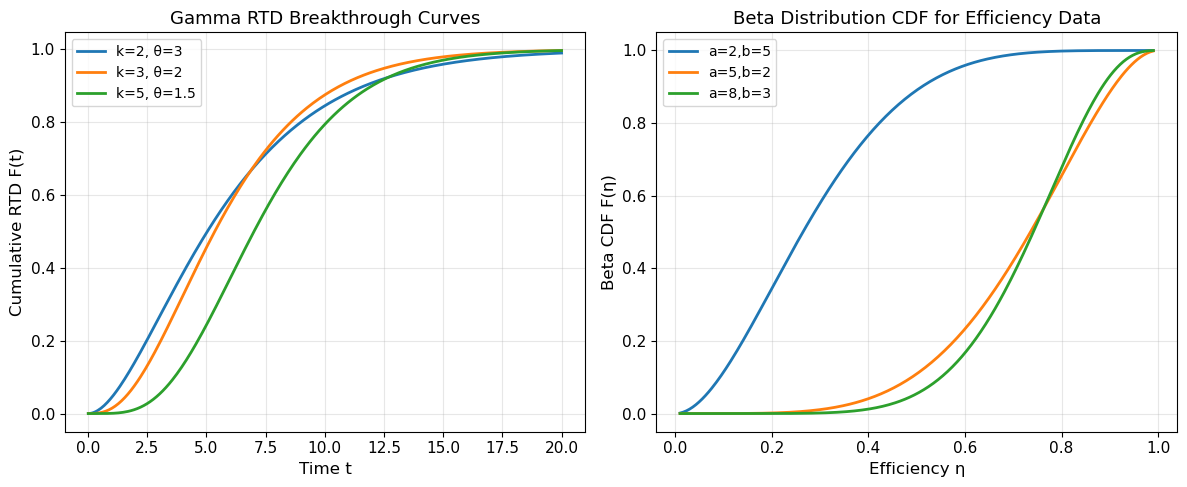


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U02_unit_ops_rtd_beta.png


In [17]:
# ================================================================
# 2. 單操（Unit Operations）— scipy.special 關鍵函式演練
# ================================================================

print("=" * 60)
print("U1/U2) gammainc / gammaincc / gammaincinv — RTD 穿透曲線")
print("=" * 60)
k, theta = 3.0, 2.0
t = np.array([0.5, 2.0, 4.0, 8.0])
F = special.gammainc(k, t/theta)   # CDF
S = special.gammaincc(k, t/theta)  # Survival
print(f"  t     = {t}")
print(f"  F(t)  = {F.round(4)}  (穿透比例)")
print(f"  S(t)  = {S.round(4)}  (未穿透比例)")
print(f"  F+S=1? {np.allclose(F+S, 1.0)}")
# 反推目標操作時間
p_target = np.array([0.50, 0.90, 0.95])
x_inv = special.gammaincinv(k, p_target)
t_star = theta * x_inv
print(f"\n  目標達標機率 p = {p_target}")
print(f"  所需時間 t*   = {t_star.round(3)}")

print("\n" + "=" * 60)
print("U3–U5) beta / betaln / betainc / betaincinv — 效率分佈建模")
print("=" * 60)
a_b, b_b = 8.0, 3.0
B = special.beta(a_b, b_b)
logB = special.betaln(a_b, b_b)
print(f"  B(8,3)         = {B:.6e}")
print(f"  exp(betaln)    = {np.exp(logB):.6e}  (應與 B 相等)")
x_vals = np.array([0.2, 0.5, 0.8])
F_beta = special.betainc(a_b, b_b, x_vals)
print(f"  Beta CDF F(x)  = {F_beta.round(4)}")
p_q = np.array([0.05, 0.50, 0.95])
eta_q = special.betaincinv(a_b, b_b, p_q)
print(f"  Beta 分位數    = {eta_q.round(4)}")
print(f"  驗證 CDF(分位數)= {special.betainc(a_b, b_b, eta_q).round(4)}")

print("\n" + "=" * 60)
print("U6/U7) psi / polygamma — Gamma/Beta MLE 估參")
print("=" * 60)
x_psi = np.array([0.5, 1.0, 2.0, 5.0])
print(f"  psi(x)          = {special.psi(x_psi).round(4)}")
print(f"  polygamma(1,x)  = {special.polygamma(1, x_psi).round(4)}")

print("\n" + "=" * 60)
print("U8) erf / erfc — 層析前緣展寬（穿透曲線）")
print("=" * 60)
x_pos, v, D, t_val = 1.0, 0.2, 1e-3, 50.0
z = (x_pos - v*t_val) / (2*np.sqrt(D*t_val))
c_ratio = 0.5 * special.erfc(z)
print(f"  z = {z:.4f}")
print(f"  C/C0 ≈ {c_ratio:.6f}  (erfc 計算)")
print(f"  C/C0 ≈ {0.5*(1-special.erf(z)):.6f}  (1-erf 計算，應相同)")

print("\n" + "=" * 60)
print("U9) exp1 — E1 指數積分（衰減核）")
print("=" * 60)
x_e1 = np.array([1e-6, 1e-3, 0.1, 1.0])
E1 = special.exp1(x_e1)
print(f"  x  = {x_e1}")
print(f"  E1 = {E1.round(4)}")

print("\n" + "=" * 60)
print("U10) logsumexp — 混合 RTD 穩定 log-likelihood")
print("=" * 60)
a_lg = np.array([0.0, -50.0, -200.0])
w_lg = np.array([0.9, 0.09, 0.01])
stable = logsumexp(a_lg + np.log(w_lg))
naive  = np.log(np.sum(w_lg * np.exp(a_lg)))
print(f"  stable logsumexp = {stable:.6f}")
print(f"  naive log-sum    = {naive:.6f}  (應相同)")

# --- RTD 穿透曲線視覺化 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

t_plot = np.linspace(0.01, 20, 300)
for k_val, theta_val, label in [(2, 3, 'k=2, θ=3'), (3, 2, 'k=3, θ=2'), (5, 1.5, 'k=5, θ=1.5')]:
    F_plot = special.gammainc(k_val, t_plot/theta_val)
    ax1.plot(t_plot, F_plot, label=label)
ax1.set_xlabel('Time t')
ax1.set_ylabel('Cumulative RTD F(t)')
ax1.set_title('Gamma RTD Breakthrough Curves')
ax1.legend()

x_eff = np.linspace(0.01, 0.99, 300)
for a_v, b_v, label in [(2, 5, 'a=2,b=5'), (5, 2, 'a=5,b=2'), (8, 3, 'a=8,b=3')]:
    F_eff = special.betainc(a_v, b_v, x_eff)
    ax2.plot(x_eff, F_eff, label=label)
ax2.set_xlabel('Efficiency η')
ax2.set_ylabel('Beta CDF F(η)')
ax2.set_title('Beta Distribution CDF for Efficiency Data')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'U02_unit_ops_rtd_beta.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U02_unit_ops_rtd_beta.png'}")

---
### 3. 傳輸現象（Transport Phenomena） — Top 10 Special Functions

**適用場景**：半無限域非穩態擴散/熱傳解析解、圓柱座標 Bessel PDE。

| 函式 | 化工應用 |
|---|---|
| `erf` | 半無限域擴散/導熱（瞬時表面濃度突變） |
| `erfc / erfcx` | 前緣濃度計算（大 z 時 erfcx 更精確） |
| `erfcx` | 重建 erfc（精度驗證用） |
| `erfcinv` | 由量測濃度反推穿透深度 |
| `exp1` | 瞬態點源衰減積分（E1） |
| `expi` | 對流-擴散解析項（Ei 函式） |
| `jv / j0` | 圓柱座標 Bessel J（導熱/質傳特徵函式） |
| `yv / y0` | 圓柱座標 Bessel Y（環形間隙幾何） |
| `iv / i0` | 修正 Bessel I（含反應衰減項的圓柱擴散） |
| `kv / k0` | 修正 Bessel K（外場衰減解） |

T1/T2) erf / erfc / erfcx — 半無限域非穩態擴散
  eta              = [0.026 0.053 0.132]
  erfc(eta)        = [0.970271 0.940584 0.852179]
  erfcx(eta)       = [0.970946 0.943201 0.867103]  (縮放版，大 z 更精確)

T3) erfcx 精度驗證
  erfc(z)        = [2.20904970e-05 1.53745979e-12 2.08848758e-45]
  erfcx 重建     = [2.20904970e-05 1.53745979e-12 2.08848758e-45]
  相對誤差       = [1.53375082e-16 0.00000000e+00 1.48983775e-16]

T4) erfcinv — 由量測濃度反推穿透深度
  C/Cs = [0.9 0.5 0.1]
  穿透深度 x (m) = [0.000337 0.00181  0.004414]

T7–T10) Bessel 函式 j0, y0, i0, k0
  x = [ 0.1   2.58  5.05  7.52 10.  ]
  J0(x) = [ 0.9975 -0.0849 -0.1611  0.2629 -0.2459]
  Y0(x) = [-1.5342  0.4859 -0.3155  0.1237  0.0557]
  I0(x) = [1.0025000e+00 3.4852000e+00 2.8485100e+01 2.7447490e+02 2.8157166e+03]
  K0(x) = [2.4271e+00 5.7100e-02 3.5000e-03 2.0000e-04 0.0000e+00]


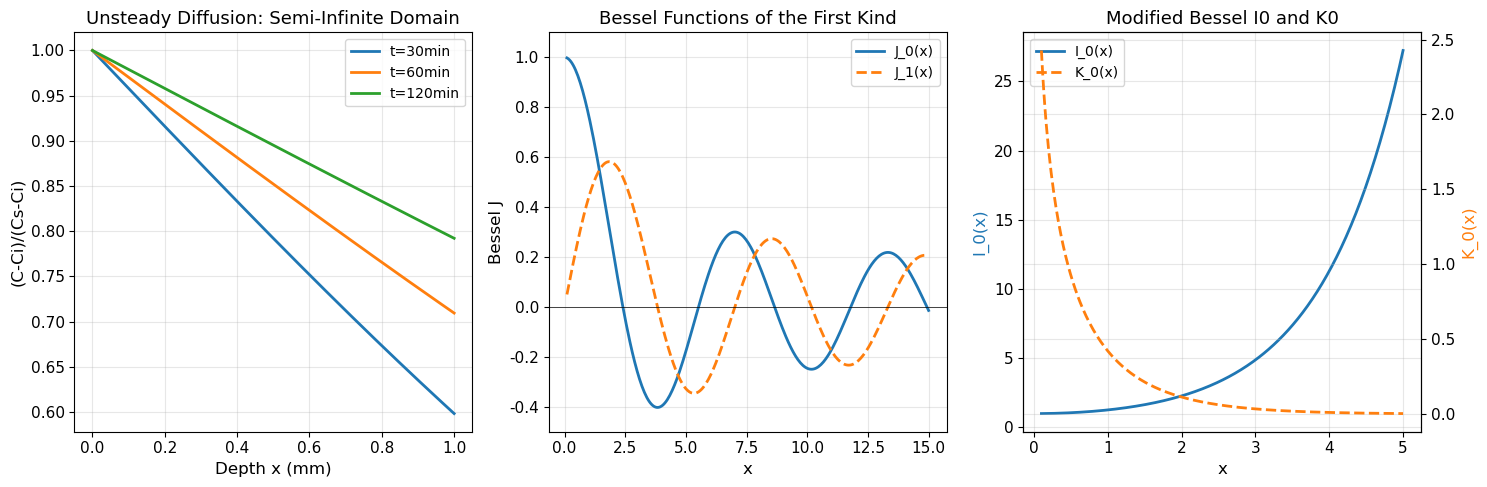


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U03_transport_bessel.png


In [18]:
# ================================================================
# 3. 傳輸現象（Transport Phenomena）— scipy.special 關鍵函式演練
# ================================================================

print("=" * 60)
print("T1/T2) erf / erfc / erfcx — 半無限域非穩態擴散")
print("=" * 60)
D_diff, t_diff = 1e-9, 3600.0          # 擴散係數 m²/s，時間 3600s
x_arr = np.array([1e-4, 2e-4, 5e-4])   # 位置 m
eta = x_arr / (2*np.sqrt(D_diff*t_diff))
c_norm = special.erfc(eta)              # (C-Ci)/(Cs-Ci)
print(f"  eta              = {eta.round(3)}")
print(f"  erfc(eta)        = {c_norm.round(6)}")
print(f"  erfcx(eta)       = {special.erfcx(eta).round(6)}  (縮放版，大 z 更精確)")

print("\n" + "=" * 60)
print("T3) erfcx 精度驗證")
print("=" * 60)
z_lg = np.array([3.0, 5.0, 10.0])
erfc_direct = special.erfc(z_lg)
erfc_recon  = np.exp(-z_lg**2) * special.erfcx(z_lg)
print(f"  erfc(z)        = {erfc_direct}")
print(f"  erfcx 重建     = {erfc_recon}")
print(f"  相對誤差       = {np.abs(erfc_recon-erfc_direct)/np.maximum(erfc_direct,1e-320)}")

print("\n" + "=" * 60)
print("T4) erfcinv — 由量測濃度反推穿透深度")
print("=" * 60)
C_ratio = np.array([0.9, 0.5, 0.1])   # C/Cs
z_inv   = special.erfcinv(C_ratio)
x_pos   = 2*np.sqrt(D_diff*t_diff)*z_inv
print(f"  C/Cs = {C_ratio}")
print(f"  穿透深度 x (m) = {x_pos.round(6)}")

print("\n" + "=" * 60)
print("T7–T10) Bessel 函式 j0, y0, i0, k0")
print("=" * 60)
x_bessel = np.linspace(0.1, 10, 5)
print(f"  x = {x_bessel.round(2)}")
print(f"  J0(x) = {special.j0(x_bessel).round(4)}")
print(f"  Y0(x) = {special.y0(x_bessel).round(4)}")
print(f"  I0(x) = {special.i0(x_bessel).round(4)}")
print(f"  K0(x) = {special.k0(x_bessel).round(4)}")

# --- 視覺化：非穩態擴散濃度剖面 & Bessel 函式 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (1) 非穩態擴散濃度剖面
x_plot = np.linspace(0, 1e-3, 300)
for t_val, label in [(1800, 't=30min'), (3600, 't=60min'), (7200, 't=120min')]:
    eta_p = x_plot / (2*np.sqrt(D_diff*t_val))
    c_p = special.erfc(eta_p)
    axes[0].plot(x_plot*1e3, c_p, label=label)
axes[0].set_xlabel('Depth x (mm)')
axes[0].set_ylabel('(C-Ci)/(Cs-Ci)')
axes[0].set_title('Unsteady Diffusion: Semi-Infinite Domain')
axes[0].legend()

# (2) Bessel J0 / Y0
x_bv = np.linspace(0.1, 15, 300)
axes[1].plot(x_bv, special.j0(x_bv), label='J_0(x)')
axes[1].plot(x_bv, special.jv(1, x_bv), label='J_1(x)', linestyle='--')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Bessel J')
axes[1].set_title('Bessel Functions of the First Kind')
axes[1].legend()
axes[1].set_ylim(-0.5, 1.1)

# (3) Modified Bessel I0 / K0
x_ik = np.linspace(0.1, 5, 300)
ax3_twin = axes[2].twinx()
axes[2].plot(x_ik, special.i0(x_ik), label='I_0(x)', color='C0')
ax3_twin.plot(x_ik, special.k0(x_ik), label='K_0(x)', color='C1', linestyle='--')
axes[2].set_xlabel('x')
axes[2].set_ylabel('I_0(x)', color='C0')
ax3_twin.set_ylabel('K_0(x)', color='C1')
axes[2].set_title('Modified Bessel I0 and K0')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
axes[2].legend(lines1+lines2, labels1+labels2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'U03_transport_bessel.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U03_transport_bessel.png'}")

---
### 4. 反應工程（Reaction Engineering） — Top 10 Special Functions

**適用場景**：動力學封閉解、觸媒顆粒有效因子、RTD 累積轉化、數值穩定目標函式。

| 函式 | 化工應用 |
|---|---|
| `lambertw` | Langmuir-Hinshelwood / Monod 型動力學的封閉解 |
| `iv` (I1/I0) | 圓柱觸媒顆粒有效因子 η（Thiele modulus） |
| `kv` (K1/K0) | 外場衰減型觸媒層解 |
| `jv` (J0/J1) | 顆粒內純擴散特徵函式展開 |
| `gamma / gammaln` | 級數解係數（大參數用 gammaln 避免溢位） |
| `gammaln`（比值）| 大 Γ 比值對數計算 |
| `gammainc / gammaincc` | 累積轉化率 P+Q=1 驗證 |
| `exprel` | 小轉化率的 (exp(x)-1)/x 穩定計算 |
| `xlogy` | 含 $x \cdot \log(y)$ 的目標函式（ $0 \cdot \log 0 = 0$ ） |
| `logsumexp`（帶權重）| 多機制速率模型的混合 log-sum |

R1) lambertw — 動力學封閉解（Lambert W）
  k        = [ 0.1  1.  10. ]
  W(k)     = [0.091277 0.567143 1.745528]
  驗證 x*exp(x) = k? True

R2) iv(I1/I0) — 圓柱觸媒有效因子（Thiele modulus）
  Thiele φ     = [ 0.1  0.5  1.   2.   5.  10. ]
  η (cylinder)  = [0.9988 0.97   0.8928 0.6978 0.3574 0.1897]
  η (sphere)    = [0.9993 0.9837 0.9391 0.806  0.4801 0.27  ]

R5/R6) gamma / gammaln — 大 n 係數（避免溢位）
  Gamma(n+1)   = [1.00000000e+00 1.20000000e+02 3.62880000e+06 3.04140932e+64]
  exp(gammaln) = [1.00000000e+00 1.20000000e+02 3.62880000e+06 3.04140932e+64]

R7) gammainc / gammaincc — 累積轉化 P+Q=1
  x = [0.1 1.  5. ],  P = [9.000e-04 1.509e-01 9.248e-01],  Q = [0.9991 0.8491 0.0752]
  P+Q=1? True

R8) exprel — 小轉化率極限 (exp(x)-1)/x
  naive  = [1.0000889  0.99999999 1.00005    1.05170918]
  stable = [1.         1.         1.00005    1.05170918]

R9) xlogy — 0*log(0)=0 目標函式穩定計算
  xlogy(x,y) = [ 0.         -0.69314718 -4.60517019]
  naive x*log(y) = [        nan -0.69314718 -4.60517019]  (含 nan/inf)


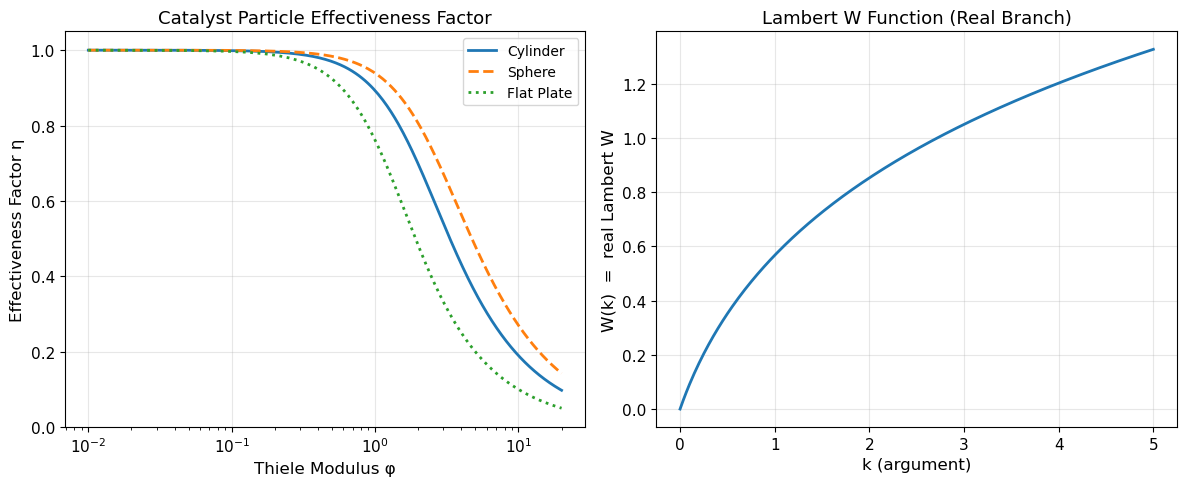


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U04_reaction_thiele_lambertw.png


In [19]:
# ================================================================
# 4. 反應工程（Reaction Engineering）— scipy.special 關鍵函式演練
# ================================================================

print("=" * 60)
print("R1) lambertw — 動力學封閉解（Lambert W）")
print("=" * 60)
k_vals = np.array([0.1, 1.0, 10.0])
W = special.lambertw(k_vals)    # 回傳複數（虛部應 ≈ 0）
print(f"  k        = {k_vals}")
print(f"  W(k)     = {W.real.round(6)}")
print(f"  驗證 x*exp(x) = k? {np.allclose((W*np.exp(W)).real, k_vals)}")

print("\n" + "=" * 60)
print("R2) iv(I1/I0) — 圓柱觸媒有效因子（Thiele modulus）")
print("=" * 60)
phi = np.array([0.1, 0.5, 1.0, 2.0, 5.0, 10.0])
I0 = special.iv(0, phi)
I1 = special.iv(1, phi)
# 圓柱形有效因子：η = 2*I1(φ) / (φ * I0(φ))
eta_cyl = 2*I1 / (phi * I0)
# 球形有效因子：η = (3/φ²)(φ*coth(φ) - 1)
eta_sph = 3 * (1/np.tanh(phi) - 1/phi) / phi
print(f"  Thiele φ     = {phi}")
print(f"  η (cylinder)  = {eta_cyl.round(4)}")
print(f"  η (sphere)    = {eta_sph.round(4)}")

print("\n" + "=" * 60)
print("R5/R6) gamma / gammaln — 大 n 係數（避免溢位）")
print("=" * 60)
n_arr = np.array([1.0, 5.0, 10.0, 50.0])
print(f"  Gamma(n+1)   = {special.gamma(n_arr+1)}")
print(f"  exp(gammaln) = {np.exp(special.gammaln(n_arr+1))}")

print("\n" + "=" * 60)
print("R7) gammainc / gammaincc — 累積轉化 P+Q=1")
print("=" * 60)
a_r, x_r = 2.5, np.array([0.1, 1.0, 5.0])
P = special.gammainc(a_r, x_r)
Q = special.gammaincc(a_r, x_r)
print(f"  x = {x_r},  P = {P.round(4)},  Q = {Q.round(4)}")
print(f"  P+Q=1? {np.allclose(P+Q, 1.0)}")

print("\n" + "=" * 60)
print("R8) exprel — 小轉化率極限 (exp(x)-1)/x")
print("=" * 60)
x_sm = np.array([1e-12, 1e-8, 1e-4, 0.1])
print(f"  naive  = {(np.exp(x_sm)-1)/x_sm}")
print(f"  stable = {special.exprel(x_sm)}")

print("\n" + "=" * 60)
print("R9) xlogy — 0*log(0)=0 目標函式穩定計算")
print("=" * 60)
x_xl = np.array([0.0, 1.0, 2.0])
y_xl = np.array([0.0, 0.5, 0.1])
print(f"  xlogy(x,y) = {special.xlogy(x_xl, y_xl)}")
print(f"  naive x*log(y) = {x_xl*np.log(y_xl)}  (含 nan/inf)")

# --- 視覺化：Thiele modulus η - φ 曲線 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

phi_p = np.linspace(0.01, 20, 500)
I0p = special.iv(0, phi_p)
I1p = special.iv(1, phi_p)
eta_cyl_p = 2*I1p / (phi_p * I0p)
eta_sph_p = 3 * (1/np.tanh(phi_p) - 1/phi_p) / phi_p
eta_flat   = np.tanh(phi_p) / phi_p   # 平板
ax1.semilogx(phi_p, eta_cyl_p, label='Cylinder')
ax1.semilogx(phi_p, eta_sph_p, label='Sphere', linestyle='--')
ax1.semilogx(phi_p, eta_flat,  label='Flat Plate', linestyle=':')
ax1.set_xlabel('Thiele Modulus φ')
ax1.set_ylabel('Effectiveness Factor η')
ax1.set_title('Catalyst Particle Effectiveness Factor')
ax1.legend()
ax1.set_ylim(0, 1.05)

# Lambert W 函式曲線
k_plot = np.linspace(0, 5, 300)
W_plot = special.lambertw(k_plot).real
ax2.plot(k_plot, W_plot, color='C0')
ax2.set_xlabel('k (argument)')
ax2.set_ylabel('W(k)  =  real Lambert W')
ax2.set_title('Lambert W Function (Real Branch)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'U04_reaction_thiele_lambertw.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U04_reaction_thiele_lambertw.png'}")

---
### 5. 熱力學（Thermodynamics） — Top 10 Special Functions

**適用場景**：統計熱力學配分函數、理想混合熵計算、Standard Normal CDF / Riemann $\zeta$ 函式。

| 函式 | 化工應用 |
|---|---|
| `logsumexp` | 統計熱力學配分函數 $\ln Z$ （Boltzmann 加總） |
| `expm1` | 小量自由能修正 $\exp(\Delta G/RT)-1$ |
| `log1p` | 小量修正 $\ln(1+\varepsilon)$ （熱力學微小修正） |
| `xlogy` | 理想混合熵 $-\sum x \cdot \ln x$ （ $0 \cdot \ln 0 = 0$ ） |
| `gamma(0.5)` | $\Gamma(1/2)=\sqrt{\pi}$ （基本積分常數） |
| `gammaln` | 大參數比值（log-domain） |
| `psi` | $\dfrac{d}{dx}\ln\Gamma(x)$ （digamma） |
| `polygamma` | $\dfrac{d^2}{dx^2}\ln\Gamma(x)$ （trigamma / Hessian） |
| `erf` & `ndtr` | 正態 CDF 兩種等價計算 |
| `zeta(2,1)` | Riemann $\zeta(2) = \pi^2/6$ （低溫熱容求和修正） |

Th1) logsumexp — 配分函數 logZ（Boltzmann 加總）
  能階 E   = [ 0.  5. 20. 60.]
  logZ     = 0.000045   Z = 1.000045
  Boltzmann probs = [1. 0. 0. 0.],  sum = 1.0000

Th2/Th3) expm1 / log1p — 小量修正數值穩定
  expm1(d) stable = [1.00000000e-12 1.00000000e-08 1.00005000e-04 1.05170918e-01]
  exp(d)-1  naive = [1.00008890e-12 9.99999994e-09 1.00005000e-04 1.05170918e-01]
  log1p(e) stable = [1.00000000e-12 9.99999995e-09 9.99950003e-05 9.53101798e-02]
  log(1+e)  naive = [1.00008890e-12 9.99999989e-09 9.99950003e-05 9.53101798e-02]

Th4) xlogy — 理想混合熵 S/R = -Σ x*ln(x)
  Composition                         S/R
  ----------------------------------------
  [1. 0. 0.]                      -0.0000
  [0.5 0.5 0. ]                    0.6931
  [0.7 0.2 0.1]                    0.8018
  [0.33333333 0.33333333 0.33333333]   1.0986
  (最大混合熵在等莫耳時達到: S/R_max = 1.0986)

Th5) gamma(1/2) = sqrt(pi)
  Gamma(0.5) = 1.7724538509
  sqrt(pi)   = 1.7724538509

Th9) erf ↔ ndtr 等價關係
  via erf: [0.02275  0.158655 0.5      0.84134

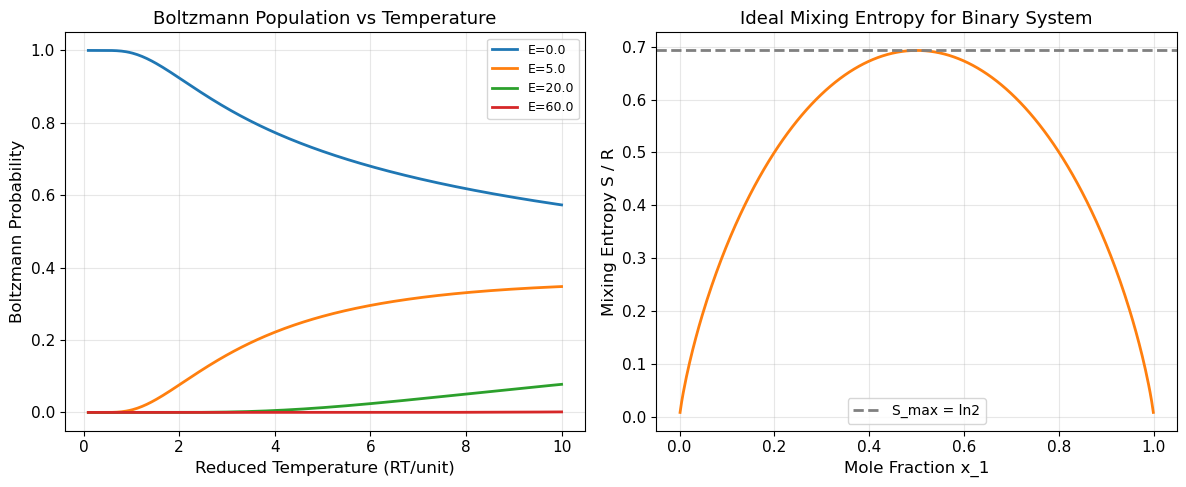


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U05_thermo_boltzmann_mixing.png


In [20]:
# ================================================================
# 5. 熱力學（Thermodynamics）— scipy.special 關鍵函式演練
# ================================================================

print("=" * 60)
print("Th1) logsumexp — 配分函數 logZ（Boltzmann 加總）")
print("=" * 60)
E_levels = np.array([0.0, 5.0, 20.0, 60.0])   # 能階 (kJ/mol)
beta_inv = 2.0                                   # 1/(RT)
logZ = logsumexp(-beta_inv * E_levels)
Z = np.exp(logZ)
p_boltz = np.exp(-beta_inv * E_levels - logZ)
print(f"  能階 E   = {E_levels}")
print(f"  logZ     = {logZ:.6f}   Z = {Z:.6f}")
print(f"  Boltzmann probs = {p_boltz.round(4)},  sum = {p_boltz.sum():.4f}")

print("\n" + "=" * 60)
print("Th2/Th3) expm1 / log1p — 小量修正數值穩定")
print("=" * 60)
d = np.array([1e-12, 1e-8, 1e-4, 0.1])
print(f"  expm1(d) stable = {special.expm1(d)}")
print(f"  exp(d)-1  naive = {np.exp(d)-1}")
eps = np.array([1e-12, 1e-8, 1e-4, 0.1])
print(f"  log1p(e) stable = {special.log1p(eps)}")
print(f"  log(1+e)  naive = {np.log(1+eps)}")

print("\n" + "=" * 60)
print("Th4) xlogy — 理想混合熵 S/R = -Σ x*ln(x)")
print("=" * 60)
compositions = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.5, 0.5, 0.0]),
    np.array([0.7, 0.2, 0.1]),
    np.array([1/3, 1/3, 1/3]),
]
print(f"  {'Composition':<30} {'S/R':>8}")
print(f"  {'-'*40}")
for x in compositions:
    S = -np.sum(special.xlogy(x, x))
    print(f"  {str(x):<30} {S:>8.4f}")
print(f"  (最大混合熵在等莫耳時達到: S/R_max = {np.log(3):.4f})")

print("\n" + "=" * 60)
print("Th5) gamma(1/2) = sqrt(pi)")
print("=" * 60)
print(f"  Gamma(0.5) = {special.gamma(0.5):.10f}")
print(f"  sqrt(pi)   = {np.sqrt(np.pi):.10f}")

print("\n" + "=" * 60)
print("Th9) erf ↔ ndtr 等價關係")
print("=" * 60)
x_norm = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
Phi_erf  = 0.5*(1 + special.erf(x_norm/np.sqrt(2)))
Phi_ndtr = special.ndtr(x_norm)
print(f"  via erf: {Phi_erf.round(6)}")
print(f"  ndtr:    {Phi_ndtr.round(6)}")
print(f"  max diff: {np.max(np.abs(Phi_erf-Phi_ndtr)):.2e}")

print("\n" + "=" * 60)
print("Th10) zeta(2) = pi^2/6")
print("=" * 60)
val_z2 = special.zeta(2.0, 1.0)
print(f"  zeta(2,1) = {val_z2:.10f}")
print(f"  pi^2/6    = {np.pi**2/6:.10f}")

# --- 視覺化：Boltzmann 分佈 & 混合熵 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (1) Boltzmann 機率 vs 溫度
T_range = np.linspace(0.1, 10, 300)   # 等效溫度
E_plot = np.array([0.0, 5.0, 20.0, 60.0])
for i, Ei in enumerate(E_plot):
    p_temp = np.zeros(len(T_range))
    for j, Tj in enumerate(T_range):
        logZ_j = logsumexp(-E_plot/Tj)
        p_temp[j] = np.exp(-Ei/Tj - logZ_j)
    ax1.plot(T_range, p_temp, label=f'E={Ei}')
ax1.set_xlabel('Reduced Temperature (RT/unit)')
ax1.set_ylabel('Boltzmann Probability')
ax1.set_title('Boltzmann Population vs Temperature')
ax1.legend(fontsize=9)

# (2) 混合熵 vs 莫耳分率（二元系）
x1_range = np.linspace(0.001, 0.999, 300)
x2_range = 1 - x1_range
S_mix = -(special.xlogy(x1_range, x1_range) + special.xlogy(x2_range, x2_range))
ax2.plot(x1_range, S_mix, color='C1')
ax2.axhline(np.log(2), color='gray', linestyle='--', label='S_max = ln2')
ax2.set_xlabel('Mole Fraction x_1')
ax2.set_ylabel('Mixing Entropy S / R')
ax2.set_title('Ideal Mixing Entropy for Binary System')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'U05_thermo_boltzmann_mixing.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U05_thermo_boltzmann_mixing.png'}")

---
### 6. 物理化學（Physical Chemistry） — Top 10 Special Functions

| 編號 | 函式 | 物化應用 | 說明 |
|------|------|---------|------|
| P1 | `polylog_series(n,z)` | Bose-Einstein / Fermi-Dirac 積分 | $\mathrm{Li}_n(z)$ 級數展開（scipy 無內建）， $\mathrm{Li}_2$ 可用 `spence(1-z)` 驗證 |
| P2 | `zeta(s,1)` | Debye 固體熱容修正 | 黎曼 $\zeta$ 函式， $\zeta(3,1)$ 出現在 Debye 模型 |
| P3 | `zetac(s)` | Planck 黑體輻射積分 | $\zeta(s)-1$ ，避免加減消去 |
| P4 | `gamma(1.5)` | 高斯型積分（Maxwell 速率分佈） | $\Gamma(3/2)=\sqrt{\pi}/2$ 出現在 3D 積分 |
| P5 | `gammaln(n+1)` | Stirling 大分子組態 | $\ln n!$ 替代，加算分子構形計數 |
| P6 | `beta(a,b)` / `betaln(a,b)` | 對稱係數 | 熱力學共存曲線 Beta 函式 |
| P7 | `psi(n)` | 自由能差計算 | digamma 函式 $\psi(n)$ |
| P8 | `polygamma(n,x)` | Fisher 資訊矩陣（物化建模） | polygamma 出現在參數不確定度 |
| P9 | `spence(1-z)` | $\mathrm{Li}_2(z)$ 配分函數對數 | Spence 函式，可計算 $\mathrm{Li}_2$ |
| P10 | `hyp2f1(a,b,c,z)` | Legendre 連帶函式 / 量子化學 | 超幾何函式 ${}_2F_1$ ，出現在量子力學徑向波函數 |

P1) polylog — Bose-Einstein 積分 Li_n(z)
  （scipy.special 無直接 polylog，使用級數展開）
  Li_1(z) = [0.10536 0.69315 2.30259 4.60517]
  Li_2(z) = [0.10262 0.58224 1.29971 1.58863]
  Li_3(z) = [0.10129 0.53721 1.04966 1.18583]
  Li_2 via series = [0.102618 0.582241 1.299715 1.588625]
  Li_2 via spence = [0.102618 0.582241 1.299715 1.588625]  (應相同)

P2) zeta(s,1) — Riemann zeta（Debye 模型）
  zeta(2,1) = 1.64493407
  zeta(3,1) = 1.20205690
  zeta(4,1) = 1.08232323
  zetac(2)   = 0.64493407  (= zeta(2)-1)
  pi^2/6 - 1 = 0.64493407

P4) gamma(1.5) — Maxwell 速率分佈 3D 積分
  Gamma(3/2) = 0.8862269255
  sqrt(pi)/2 = 0.8862269255

P5) gammaln — 大分子 ln(n!) = gammaln(n+1)
  n=   10: gammaln=15.1044  Stirling=15.0961
  n=  100: gammaln=363.7394  Stirling=363.7385
  n= 1000: gammaln=5912.1282  Stirling=5912.1281
  n=10000: gammaln=82108.9278  Stirling=82108.9278

P10) hyp2f1 — 超幾何函式（量子化學徑向波函數）
  hyp2f1(1,1,2,0.5) = 1.38629436
  -log(1-0.5)/0.5 = 1.38629436  (expected)


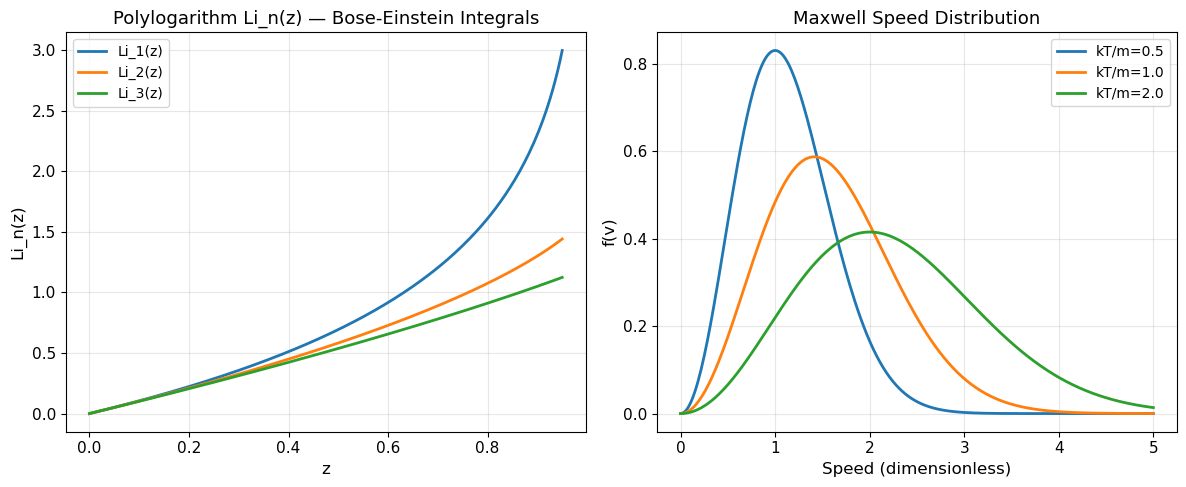


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U06_physchem_polylog_maxwell.png


In [21]:
# ================================================================
# 6. 物理化學（Physical Chemistry）— scipy.special 關鍵函式演練
# ================================================================

# --- 自訂 polylog 函式 (scipy.special 無內建 polylog) ---
# Li_n(z) = sum_{k=1}^{inf} z^k / k^n，對 |z| < 1 收斂
def polylog_series(n, z):
    """Polylogarithm Li_n(z) via series expansion. Valid for |z| < 1."""
    z = np.asarray(z, dtype=float)
    result = np.zeros_like(z)
    z_k = np.ones_like(z)
    for k in range(1, 1000):
        z_k = z_k * z
        term = z_k / float(k)**n
        result += term
        if np.max(np.abs(term)) < 1e-14:
            break
    return result

print("=" * 60)
print("P1) polylog — Bose-Einstein 積分 Li_n(z)")
print("  （scipy.special 無直接 polylog，使用級數展開）")
print("=" * 60)
z_vals = np.array([0.1, 0.5, 0.9, 0.99])
for n in [1, 2, 3]:
    li_n = polylog_series(n, z_vals)
    print(f"  Li_{n}(z) = {li_n.round(5)}")
# 驗證 Li_2 vs scipy.special.spence (spence(z) = Li_2(1-z))
li2_series = polylog_series(2, z_vals)
li2_spence  = special.spence(1.0 - z_vals)
print(f"  Li_2 via series = {li2_series.round(6)}")
print(f"  Li_2 via spence = {li2_spence.round(6)}  (應相同)")

print("\n" + "=" * 60)
print("P2) zeta(s,1) — Riemann zeta（Debye 模型）")
print("=" * 60)
for s in [2, 3, 4]:
    val = special.zeta(float(s), 1.0)
    print(f"  zeta({s},1) = {val:.8f}")
print(f"  zetac(2)   = {special.zetac(2.0):.8f}  (= zeta(2)-1)")
print(f"  pi^2/6 - 1 = {np.pi**2/6 - 1:.8f}")

print("\n" + "=" * 60)
print("P4) gamma(1.5) — Maxwell 速率分佈 3D 積分")
print("=" * 60)
print(f"  Gamma(3/2) = {special.gamma(1.5):.10f}")
print(f"  sqrt(pi)/2 = {np.sqrt(np.pi)/2:.10f}")

print("\n" + "=" * 60)
print("P5) gammaln — 大分子 ln(n!) = gammaln(n+1)")
print("=" * 60)
n_vals = [10, 100, 1000, 10000]
for n in n_vals:
    ln_fact = special.gammaln(n + 1)
    stirling = n*np.log(n) - n + 0.5*np.log(2*np.pi*n)
    print(f"  n={n:5d}: gammaln={ln_fact:.4f}  Stirling={stirling:.4f}")

print("\n" + "=" * 60)
print("P10) hyp2f1 — 超幾何函式（量子化學徑向波函數）")
print("=" * 60)
z_hyp = 0.5
print(f"  hyp2f1(1,1,2,{z_hyp}) = {special.hyp2f1(1.0,1.0,2.0,z_hyp):.8f}")
print(f"  -log(1-{z_hyp})/{z_hyp} = {-np.log(1-z_hyp)/z_hyp:.8f}  (expected)")

# --- 視覺化：polylog & Maxwell 速率分佈 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (1) polylog Li_n(z) for n=1,2,3
z_range = np.linspace(0.0, 0.95, 200)
for n in [1, 2, 3]:
    ax1.plot(z_range, polylog_series(n, z_range), label=f'Li_{n}(z)')
ax1.set_xlabel('z')
ax1.set_ylabel('Li_n(z)')
ax1.set_title('Polylogarithm Li_n(z) — Bose-Einstein Integrals')
ax1.legend(loc='upper left')

# (2) Maxwell 速率分佈 f(v) ~ v^2 * exp(-mv^2/2kT)
v_range = np.linspace(0, 5, 300)
kT_mass_vals = [0.5, 1.0, 2.0]
for kTm in kT_mass_vals:
    f_v = 4*np.pi * (1/(2*np.pi*kTm))**1.5 * v_range**2 * np.exp(-v_range**2/(2*kTm))
    ax2.plot(v_range, f_v, label=f'kT/m={kTm}')
ax2.set_xlabel('Speed (dimensionless)')
ax2.set_ylabel('f(v)')
ax2.set_title('Maxwell Speed Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'U06_physchem_polylog_maxwell.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U06_physchem_polylog_maxwell.png'}")

---
### 7. 程序控制（Process Control） — Top 10 Special Functions

| 編號 | 函式 | 控制應用 | 說明 |
|------|------|---------|------|
| C1 | `logsumexp` | log-sum-exp（MPC 軟最大） | 穩定計算 $\ln(\sum\exp)$ |
| C2 | `xlogy(p,q)` | KL 散度（貝式濾波器） | $p \cdot \ln q$ ， $0 \cdot \ln 0 = 0$ |
| C3 | `xlog1py(p,q)` | 二項 log-likelihood | $p \cdot \ln(1+q)$ |
| C4 | `expm1(x)` | 小量一階動態響應 | 數值穩定 $e^x-1$ |
| C5 | `log1p(x)` | 增益對數近似 | $\ln(1+x)$ 小量穩定 |
| C6 | `ndtr(z)` | 過程能力指標（Cpk → p-value） | 標準常態 CDF $\Phi(z)$ |
| C7 | `ndtri(p)` | 警報閾值設定 | 標準常態逆函式 $z = \Phi^{-1}(p)$ |
| C8 | `erf(x)` | 一階系統步階響應 | erf 出現在擴散/積分響應 |
| C9 | `erfc(x)` | 尾端觀測機率 | $1-\mathrm{erf}$ ，數值穩定尾端計算 |
| C10 | `psi(x)` / `polygamma(1,x)` | Fisher 資訊（MLE 在線辨識） | digamma/trigamma 在最大概似估計 |

C1) logsumexp — 軟最大（softmax weights）
  log_scores = [1.  2.  3.  0.5]
  softmax    = [0.0854 0.2321 0.6308 0.0518],  sum = 1.0000

C2) xlogy / xlog1py — KL 散度
  p     = [0.6 0.3 0.1]
  q     = [0.5 0.4 0.1]
  KL(p||q) = 0.023088  (>= 0)

C4/C5) expm1 / log1p — 小量動態響應
  expm1(-dt/tau) = [-1.00000000e-10 -9.99999500e-07 -9.99500167e-04 -9.51625820e-02]

C6/C7) ndtr / ndtri — 過程能力 & 警報閾值
  Cpk=1.00, z=3.0, defective PPM=2699.80
  Cpk=1.33, z=4.0, defective PPM=66.07
  Cpk=1.67, z=5.0, defective PPM=0.54
  Cpk=2.00, z=6.0, defective PPM=0.00
  α=0.9900 → alarm z-threshold = 2.3263
  α=0.9990 → alarm z-threshold = 3.0902
  α=0.9999 → alarm z-threshold = 3.7190

C10) psi / polygamma — MLE Fisher 資訊
  psi(alpha=5) = 1.506118  (digamma)
  polygamma(1,5) = 0.221323  (trigamma = -d^2logL/dalpha^2)


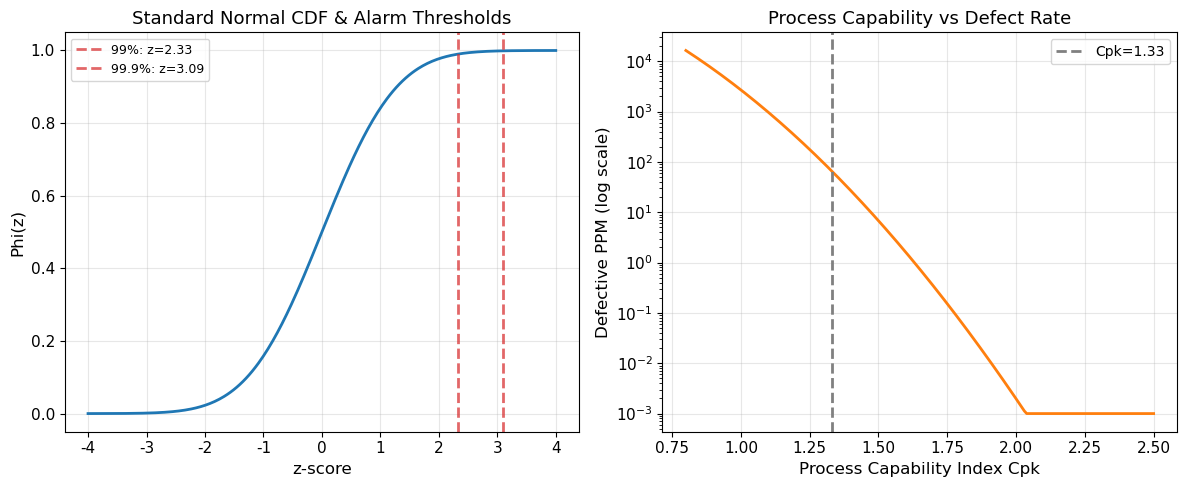


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U07_control_ndtr_cpk.png


In [22]:
# ================================================================
# 7. 程序控制（Process Control）— scipy.special 關鍵函式演練
# ================================================================

print("=" * 60)
print("C1) logsumexp — 軟最大（softmax weights）")
print("=" * 60)
log_scores = np.array([1.0, 2.0, 3.0, 0.5])
log_Z = logsumexp(log_scores)
softmax_w = np.exp(log_scores - log_Z)
print(f"  log_scores = {log_scores}")
print(f"  softmax    = {softmax_w.round(4)},  sum = {softmax_w.sum():.4f}")

print("\n" + "=" * 60)
print("C2) xlogy / xlog1py — KL 散度")
print("=" * 60)
p_true = np.array([0.6, 0.3, 0.1])
q_model = np.array([0.5, 0.4, 0.1])
KL_pq = np.sum(special.xlogy(p_true, p_true/q_model))
print(f"  p     = {p_true}")
print(f"  q     = {q_model}")
print(f"  KL(p||q) = {KL_pq:.6f}  (>= 0)")

print("\n" + "=" * 60)
print("C4/C5) expm1 / log1p — 小量動態響應")
print("=" * 60)
dt = np.array([1e-10, 1e-6, 1e-3, 0.1])
tau = 1.0
step_resp = special.expm1(-dt/tau)   # exp(-dt/tau) - 1
print(f"  expm1(-dt/tau) = {step_resp}")

print("\n" + "=" * 60)
print("C6/C7) ndtr / ndtri — 過程能力 & 警報閾值")
print("=" * 60)
# 過程能力：Cpk = 1.33 → PPM defect
Cpk_vals = np.array([1.0, 1.33, 1.67, 2.0])
for Cpk in Cpk_vals:
    z_score = 3 * Cpk
    ppm_defect = 2.0 * (1 - special.ndtr(z_score)) * 1e6
    print(f"  Cpk={Cpk:.2f}, z={z_score:.1f}, defective PPM={ppm_defect:.2f}")

# 警報閾值設定
for alpha in [0.99, 0.999, 0.9999]:
    z_alarm = special.ndtri(alpha)
    print(f"  α={alpha:.4f} → alarm z-threshold = {z_alarm:.4f}")

print("\n" + "=" * 60)
print("C10) psi / polygamma — MLE Fisher 資訊")
print("=" * 60)
alpha_gamma = 5.0
print(f"  psi(alpha=5) = {special.psi(alpha_gamma):.6f}  (digamma)")
print(f"  polygamma(1,5) = {special.polygamma(1, alpha_gamma):.6f}  (trigamma = -d^2logL/dalpha^2)")

# --- 視覺化：警報閾值 & 過程能力 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (1) 標準常態 CDF & 警報閾值線
z_range = np.linspace(-4, 4, 300)
ax1.plot(z_range, special.ndtr(z_range), color='C0')
for a_thresh, label in [(0.99, '99%'), (0.999, '99.9%')]:
    z_t = special.ndtri(a_thresh)
    ax1.axvline(z_t, color='C3', linestyle='--', alpha=0.7, label=f'{label}: z={z_t:.2f}')
ax1.set_xlabel('z-score')
ax1.set_ylabel('Phi(z)')
ax1.set_title('Standard Normal CDF & Alarm Thresholds')
ax1.legend(fontsize=9)

# (2) Cpk vs Defective PPM (log scale)
Cpk_range = np.linspace(0.8, 2.5, 200)
ppm_range = 2.0 * (1 - special.ndtr(3 * Cpk_range)) * 1e6
ppm_range = np.maximum(ppm_range, 1e-3)
ax2.semilogy(Cpk_range, ppm_range, color='C1')
ax2.axvline(1.33, color='gray', linestyle='--', label='Cpk=1.33')
ax2.set_xlabel('Process Capability Index Cpk')
ax2.set_ylabel('Defective PPM (log scale)')
ax2.set_title('Process Capability vs Defect Rate')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'U07_control_ndtr_cpk.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U07_control_ndtr_cpk.png'}")

---
### 8. 工程統計（Engineering Statistics） — Top 10 Special Functions

| 編號 | 函式 | 統計應用 | 說明 |
|------|------|---------|------|
| S1 | `ndtr(z)` | z 檢定 p 值 | 標準常態 CDF，單/雙尾 p 值 |
| S2 | `ndtri(p)` | 信賴區間 z* | 標準常態逆函式 |
| S3 | `erf(x)` / `erfc(x)` | 常態尾端機率 | erf 等價 $\Phi(z\sqrt{2})$ |
| S4 | `gammainc(a,x)` | 卡方 CDF（ $P(\chi^2 < x)$ ） | 下不完全 gamma， $a=\mathrm{df}/2,\ x=\chi^2/2$ |
| S5 | `gammaincc(a,x)` | 卡方尾端（p-value） | 上不完全 gamma，SciPy chi2.sf |
| S6 | `gammainccinv(a,p)` | 卡方臨界值 $\chi^2_\alpha$ | 上不完全 gamma 逆函式 |
| S7 | `betainc(a,b,x)` | Beta CDF（二項比率信賴區間） | 正則化不完全 Beta 函式 |
| S8 | `betaincinv(a,b,p)` | 二項比率信賴界限 | Beta 逆函式，精確 Wilson 界限 |
| S9 | `psi(x)` | 伽馬分佈 MLE | digamma 出現在 MLE 積分方程 |
| S10 | `polygamma(1,x)` | 伽馬分佈 Fisher 資訊 | trigamma = $\mathrm{Var}(\log X)$ 倒數 |

S1/S2) ndtr / ndtri — z 檢定 p 值 & 信賴區間
  z=1.000: 雙尾 p-value = 0.31731
  z=1.645: 雙尾 p-value = 0.09997
  z=1.960: 雙尾 p-value = 0.05000
  z=2.576: 雙尾 p-value = 0.01000

  alpha=0.050: z* = 1.9600 (95/99/99.9% CI)
  alpha=0.010: z* = 2.5758 (95/99/99.9% CI)
  alpha=0.001: z* = 3.2905 (95/99/99.9% CI)

S4/S5/S6) gammainc/cc/inv — 卡方檢定
  χ²=15.507, df=8
  P-value (上尾) = 0.050005
  χ²_0.05 臨界值 = 15.5073

S7/S8) betainc / betaincinv — 二項比率信賴區間（Clopper-Pearson）
  n=100, k=65, p_hat=0.65
  95% Clopper-Pearson CI: [0.5482, 0.7427]

S9/S10) psi / polygamma — Gamma MLE
  alpha_hat=3.5
  psi(alpha)=1.103157  (MLE 方程中的 digamma)
  polygamma(1,alpha)=0.330358  (Fisher Info 的倒數 ≈ 1/Var)


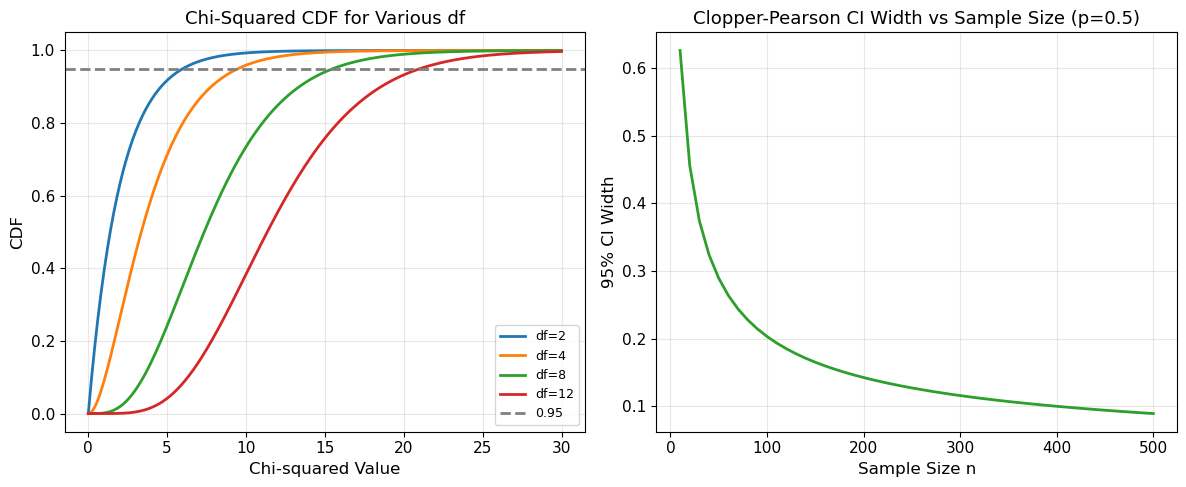


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U08_stats_chisq_beta_ci.png


In [23]:
# ================================================================
# 8. 工程統計（Engineering Statistics）— scipy.special 關鍵函式演練
# ================================================================

print("=" * 60)
print("S1/S2) ndtr / ndtri — z 檢定 p 值 & 信賴區間")
print("=" * 60)
z_test_stats = np.array([1.0, 1.645, 1.96, 2.576])
for z in z_test_stats:
    p_two = 2 * (1 - special.ndtr(z))
    print(f"  z={z:.3f}: 雙尾 p-value = {p_two:.5f}")
print()
for alpha in [0.05, 0.01, 0.001]:
    z_star = special.ndtri(1 - alpha/2)
    print(f"  alpha={alpha:.3f}: z* = {z_star:.4f} (95/99/99.9% CI)")

print("\n" + "=" * 60)
print("S4/S5/S6) gammainc/cc/inv — 卡方檢定")
print("=" * 60)
chi2_val = 15.507   # 典型卡方統計量
df = 8
a = df / 2.0
x = chi2_val / 2.0
p_value = special.gammaincc(a, x)
chi2_crit = 2 * special.gammainccinv(a, 0.05)
print(f"  χ²={chi2_val}, df={df}")
print(f"  P-value (上尾) = {p_value:.6f}")
print(f"  χ²_0.05 臨界值 = {chi2_crit:.4f}")

print("\n" + "=" * 60)
print("S7/S8) betainc / betaincinv — 二項比率信賴區間（Clopper-Pearson）")
print("=" * 60)
n_trials = 100
k_success = 65   # 觀測到 65/100 成功
alpha_ci = 0.05
lo = special.betaincinv(k_success, n_trials - k_success + 1, alpha_ci/2)
hi = special.betaincinv(k_success + 1, n_trials - k_success, 1 - alpha_ci/2)
print(f"  n={n_trials}, k={k_success}, p_hat={k_success/n_trials:.2f}")
print(f"  95% Clopper-Pearson CI: [{lo:.4f}, {hi:.4f}]")

print("\n" + "=" * 60)
print("S9/S10) psi / polygamma — Gamma MLE")
print("=" * 60)
alpha_hat = 3.5   # MLE shape 估計
psi_val = special.psi(alpha_hat)
trigamma_val = special.polygamma(1, alpha_hat)
print(f"  alpha_hat={alpha_hat}")
print(f"  psi(alpha)={psi_val:.6f}  (MLE 方程中的 digamma)")
print(f"  polygamma(1,alpha)={trigamma_val:.6f}  (Fisher Info 的倒數 ≈ 1/Var)")

# --- 視覺化：卡方分佈 CDF & Beta CI ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (1) 卡方 CDF for different df
chi2_range = np.linspace(0, 30, 300)
for df_plot in [2, 4, 8, 12]:
    a_plot = df_plot / 2.0
    cdf_plot = special.gammainc(a_plot, chi2_range/2.0)
    ax1.plot(chi2_range, cdf_plot, label=f'df={df_plot}')
ax1.axhline(0.95, color='gray', linestyle='--', label='0.95')
ax1.set_xlabel('Chi-squared Value')
ax1.set_ylabel('CDF')
ax1.set_title('Chi-Squared CDF for Various df')
ax1.legend(fontsize=9)

# (2) Clopper-Pearson CI width vs sample size
n_range = np.arange(10, 501, 10)
ci_width = np.zeros(len(n_range))
for i, n_s in enumerate(n_range):
    k_s = round(0.5 * n_s)   # 50% success rate
    lo_s = special.betaincinv(k_s, n_s - k_s + 1, 0.025)
    hi_s = special.betaincinv(k_s + 1, n_s - k_s, 0.975)
    ci_width[i] = hi_s - lo_s
ax2.plot(n_range, ci_width, color='C2')
ax2.set_xlabel('Sample Size n')
ax2.set_ylabel('95% CI Width')
ax2.set_title('Clopper-Pearson CI Width vs Sample Size (p=0.5)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'U08_stats_chisq_beta_ci.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U08_stats_chisq_beta_ci.png'}")

---
### 9. 數值方法（Numerical Methods） — Top 10 Special Functions

| 編號 | 函式 | 數值應用 | 說明 |
|------|------|---------|------|
| N1 | `eval_legendre(n,x)` | Gauss-Legendre 積分節點/係數 | Legendre 多項式 $P_n(x)$ |
| N2 | `eval_chebyt(n,x)` | Chebyshev I 類逼近 | $T_n(x)$ ，最佳均方誤差插值 |
| N3 | `eval_chebyu(n,x)` | Chebyshev II 類 | $U_n(x)$ ，延伸 Chebyshev 逼近 |
| N4 | `eval_hermite(n,x)` | Hermite（Gauss-Hermite 積分） | $H_n(x)$ ，適用 $\exp(-x^2)$ 權重積分 |
| N5 | `eval_laguerre(n,x)` | Gauss-Laguerre 積分 | $L_n(x)$ ，適用 $\exp(-x)$ 權重積分 |
| N6 | `eval_genlaguerre(n,α,x)` | 廣義 Gauss-Laguerre | $L_n^\alpha(x)$ ，徑向量子化學積分 |
| N7 | `airy(x)` | 邊界層漸近解 | $\mathrm{Ai}(x)/\mathrm{Bi}(x)$ 及其導數，WKB 法 |
| N8 | `hyp1f1(a,b,z)` | 合流超幾何函式 | $_1F_1(a;b;z)$ ，量子/統計特殊解 |
| N9 | `hyp2f1(a,b,c,z)` | 超幾何級數 | $_2F_1(a,b;c;z)$ ，各類工程台階函式 |
| N10 | `gammaln(n+1)` | 大階乘對數計算 | $\ln(n!)$ ，避免數值溢位 |

N1) eval_legendre — Legendre 多項式
  P_0(x)=[1. 1. 1. 1. 1.]
  P_1(x)=[-1.  -0.5  0.   0.5  1. ]
  P_2(x)=[ 1.    -0.125 -0.5   -0.125  1.   ]
  P_3(x)=[-1.      0.4375  0.     -0.4375  1.    ]
  P_4(x)=[ 1.     -0.2891  0.375  -0.2891  1.    ]

N2/N3) eval_chebyt / eval_chebyu — Chebyshev 多項式
  T_1(x)=[-1.  -0.5  0.   0.5  1. ]
  U_1(x)=[-2. -1.  0.  1.  2.]
  T_2(x)=[ 1.  -0.5 -1.  -0.5  1. ]
  U_2(x)=[ 3.  0. -1.  0.  3.]
  T_3(x)=[-1.  1. -0. -1.  1.]
  U_3(x)=[-4.  1. -0. -1.  4.]

N7) airy — Airy 函式（邊界層 WKB）
  x   = [-5 -2  0  1  3]
  Ai  = [0.350761 0.227407 0.355028 0.135292 0.006591]
  Bi  = [-0.138369 -0.412303  0.614927  1.207424 14.037329]

N8/N9) hyp1f1 / hyp2f1 — 超幾何函式
  hyp1f1(1, 2, z) = [1.       1.107014 1.297443 1.531926]
  (1/z)*(exp(z)-1)= [1.       1.107014 1.297443 1.531926]
  hyp2f1(1,1,2,z) = [1.       1.115718 1.386294 2.011797]
  -log(1-z)/z     = [1.       1.115718 1.386294 2.011797]

N10) gammaln — 大階乘 log(n!)
  log(100!) = gammaln(100+1) = 363.7394
  log(500!

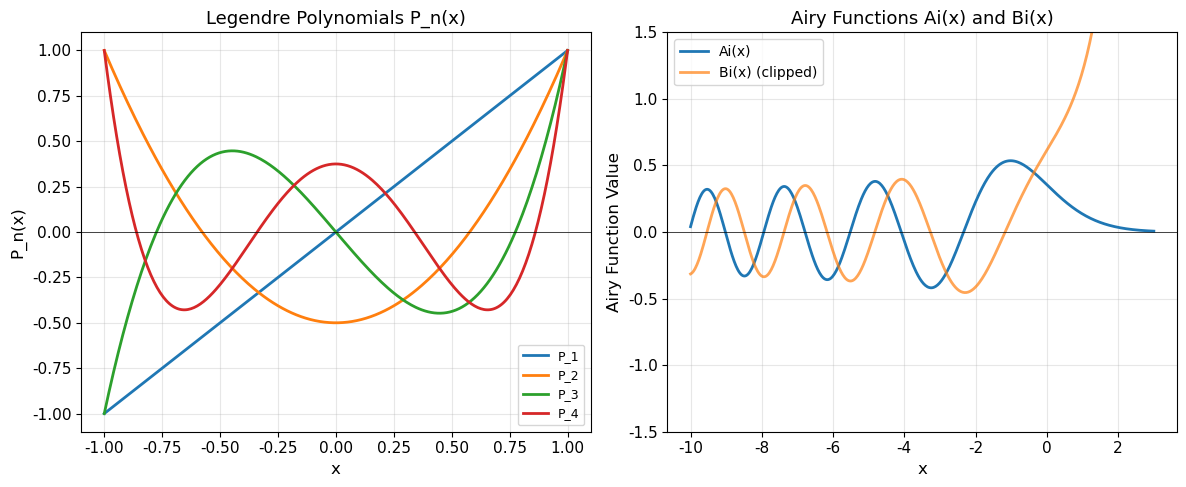


✓ 圖表已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U09_numerical_legendre_airy.png


In [24]:
# ================================================================
# 9. 數值方法（Numerical Methods）— scipy.special 關鍵函式演練
# ================================================================

print("=" * 60)
print("N1) eval_legendre — Legendre 多項式")
print("=" * 60)
x_leg = np.linspace(-1, 1, 5)
for n in range(5):
    P_n = special.eval_legendre(n, x_leg)
    print(f"  P_{n}(x)={P_n.round(4)}")

print("\n" + "=" * 60)
print("N2/N3) eval_chebyt / eval_chebyu — Chebyshev 多項式")
print("=" * 60)
x_cheb = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
for n in [1, 2, 3]:
    T_n = special.eval_chebyt(n, x_cheb)
    U_n = special.eval_chebyu(n, x_cheb)
    print(f"  T_{n}(x)={T_n.round(4)}")
    print(f"  U_{n}(x)={U_n.round(4)}")

print("\n" + "=" * 60)
print("N7) airy — Airy 函式（邊界層 WKB）")
print("=" * 60)
x_airy = np.array([-5, -2, 0, 1, 3])
Ai, Aip, Bi, Bip = special.airy(x_airy)
print(f"  x   = {x_airy}")
print(f"  Ai  = {Ai.round(6)}")
print(f"  Bi  = {Bi.round(6)}")

print("\n" + "=" * 60)
print("N8/N9) hyp1f1 / hyp2f1 — 超幾何函式")
print("=" * 60)
z_range_hyp = np.array([0.0, 0.2, 0.5, 0.8])
print("  hyp1f1(1, 2, z) =", special.hyp1f1(1.0, 2.0, z_range_hyp).round(6))
print("  (1/z)*(exp(z)-1)=", np.where(z_range_hyp==0, 1.0, (np.exp(z_range_hyp)-1)/z_range_hyp).round(6))
print("  hyp2f1(1,1,2,z) =", special.hyp2f1(1.0, 1.0, 2.0, z_range_hyp).round(6))
print("  -log(1-z)/z     =", np.where(z_range_hyp==0, 1.0, -np.log(1-z_range_hyp)/z_range_hyp).round(6))

print("\n" + "=" * 60)
print("N10) gammaln — 大階乘 log(n!)")
print("=" * 60)
big_n = [100, 500, 1000, 10000, 100000]
for n in big_n:
    print(f"  log({n}!) = gammaln({n}+1) = {special.gammaln(n+1):.4f}")

# --- 視覺化：正交多項式 & Airy 函式 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (1) Legendre + Chebyshev polynomials
x_plot = np.linspace(-1, 1, 300)
for n in range(1, 5):
    ax1.plot(x_plot, special.eval_legendre(n, x_plot), label=f'P_{n}')
ax1.set_xlabel('x')
ax1.set_ylabel('P_n(x)')
ax1.set_title('Legendre Polynomials P_n(x)')
ax1.legend(fontsize=9)
ax1.axhline(0, color='k', linewidth=0.5)

# (2) Airy functions Ai(x) and Bi(x)
x_ai = np.linspace(-10, 3, 500)
Ai_p, _, Bi_p, _ = special.airy(x_ai)
ax2.plot(x_ai, Ai_p, color='C0', label='Ai(x)')
ax2.plot(x_ai, np.clip(Bi_p, -5, 5), color='C1', label='Bi(x) (clipped)', alpha=0.7)
ax2.axhline(0, color='k', linewidth=0.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_xlabel('x')
ax2.set_ylabel('Airy Function Value')
ax2.set_title('Airy Functions Ai(x) and Bi(x)')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'U09_numerical_legendre_airy.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖表已儲存：{FIG_DIR / 'U09_numerical_legendre_airy.png'}")

---
### 10. 跨領域總整理（Cross-Subject Summary）

本節以 pandas DataFrame 整理前述八大主題中最重要的 `scipy.special` 函式，
並以熱力圖展示各函式的跨領域使用情形。

**圖例說明：**
- 橫軸：化工應用領域
- 縱軸：`scipy.special` 函式
- 色塊深淺：該函式在該領域的重要程度（2=核心、1=常用、0=較少使用）

scipy.special 函式跨化工領域重要性表：
                 UO  TP  RE  TH  PC  CT  ST  NM
gammainc/cc/inv   2   0   2   1   1   0   2   0
betainc/inv       2   0   1   0   1   0   2   0
psi/polygamma     1   0   1   0   1   1   2   0
logsumexp         1   0   0   2   2   2   1   0
erf/erfc/erfcx    1   2   1   0   0   1   1   1
erfinv/erfcinv    1   2   0   0   0   0   0   0
j0/j1/y0/y1       0   2   0   0   0   0   0   1
i0/i1/k0/k1       0   2   2   0   0   0   0   0
lambertw          0   0   2   0   0   0   0   0
iv (Bessel I)     0   0   2   0   0   0   0   0
gammaln           1   0   2   1   2   0   1   1
exprel/xlogy      0   0   1   1   0   2   0   0
expm1/log1p       0   0   0   2   0   2   0   0
ndtr/ndtri        0   0   0   1   0   2   2   0
polylog           0   0   0   0   2   0   0   1
zeta/zetac        0   0   0   1   2   0   0   1
eval_legendre     0   0   0   0   0   0   0   2
eval_chebyt       0   0   0   0   0   0   0   2
airy              0   1   0   0   0   0   0   2
hyp1f1/hyp2f1

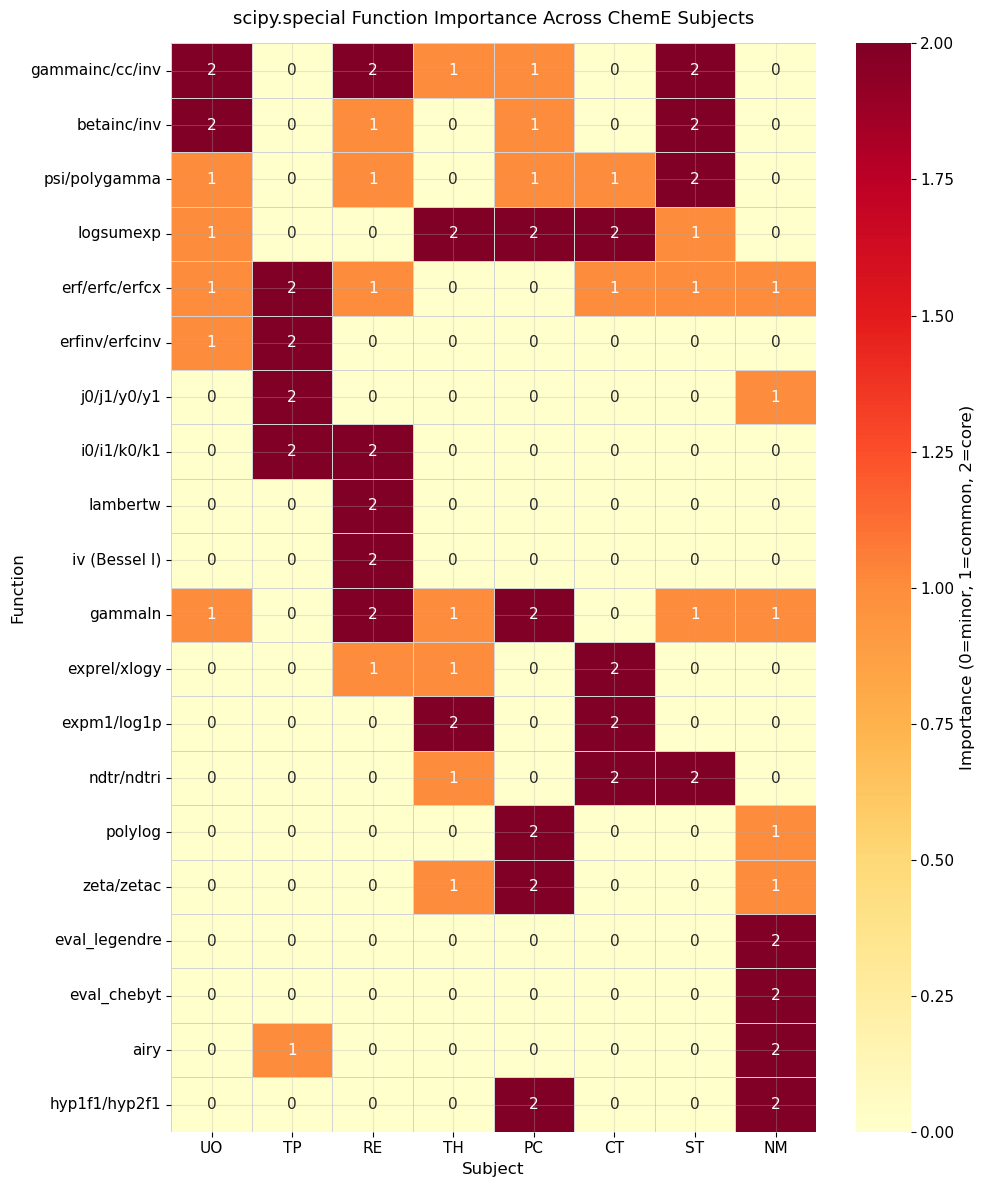

✓ 熱力圖已儲存：d:\MyGit\ChemE-3502\Unit05\outputs\Unit05_Special_Functions\figs\U10_crosssubject_heatmap.png


In [25]:
# ================================================================
# 10. 跨領域總整理 — scipy.special 函式跨主題使用熱力圖
# ================================================================
import pandas as pd

# ── 函式重要性矩陣 (2=核心應用, 1=常用, 0=較少使用) ────────────────
# 欄位：UO=單元操作, TP=輸送現象, RE=反應工程, TH=熱力學,
#       PC=物化, CT=程序控制, ST=工程統計, NM=數值方法
func_labels = [
    "gammainc/cc/inv", "betainc/inv",
    "psi/polygamma",   "logsumexp",
    "erf/erfc/erfcx",  "erfinv/erfcinv",
    "j0/j1/y0/y1",     "i0/i1/k0/k1",
    "lambertw",        "iv (Bessel I)",
    "gammaln",         "exprel/xlogy",
    "expm1/log1p",     "ndtr/ndtri",
    "polylog",         "zeta/zetac",
    "eval_legendre",   "eval_chebyt",
    "airy",            "hyp1f1/hyp2f1",
]

col_labels = ["UO", "TP", "RE", "TH", "PC", "CT", "ST", "NM"]

data_matrix = [
#   UO  TP  RE  TH  PC  CT  ST  NM
    [2,  0,  2,  1,  1,  0,  2,  0],  # gammainc/cc/inv
    [2,  0,  1,  0,  1,  0,  2,  0],  # betainc/inv
    [1,  0,  1,  0,  1,  1,  2,  0],  # psi/polygamma
    [1,  0,  0,  2,  2,  2,  1,  0],  # logsumexp
    [1,  2,  1,  0,  0,  1,  1,  1],  # erf/erfc/erfcx
    [1,  2,  0,  0,  0,  0,  0,  0],  # erfinv/erfcinv
    [0,  2,  0,  0,  0,  0,  0,  1],  # j0/j1/y0/y1
    [0,  2,  2,  0,  0,  0,  0,  0],  # i0/i1/k0/k1
    [0,  0,  2,  0,  0,  0,  0,  0],  # lambertw
    [0,  0,  2,  0,  0,  0,  0,  0],  # iv (Bessel I)
    [1,  0,  2,  1,  2,  0,  1,  1],  # gammaln
    [0,  0,  1,  1,  0,  2,  0,  0],  # exprel/xlogy
    [0,  0,  0,  2,  0,  2,  0,  0],  # expm1/log1p
    [0,  0,  0,  1,  0,  2,  2,  0],  # ndtr/ndtri
    [0,  0,  0,  0,  2,  0,  0,  1],  # polylog
    [0,  0,  0,  1,  2,  0,  0,  1],  # zeta/zetac
    [0,  0,  0,  0,  0,  0,  0,  2],  # eval_legendre
    [0,  0,  0,  0,  0,  0,  0,  2],  # eval_chebyt
    [0,  1,  0,  0,  0,  0,  0,  2],  # airy
    [0,  0,  0,  0,  2,  0,  0,  2],  # hyp1f1/hyp2f1
]

df_summary = pd.DataFrame(data_matrix, index=func_labels, columns=col_labels)
print("scipy.special 函式跨化工領域重要性表：")
print(df_summary.to_string())

# 匯出 CSV
csv_path = FIG_DIR.parent / 'scipy_special_crosssubject_table.csv'
df_summary.to_csv(csv_path, encoding='utf-8-sig')
print(f"\n✓ 表格已匯出：{csv_path}")

# --- 視覺化：熱力圖 ---
try:
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(10, 12))
    sns.heatmap(
        df_summary, annot=True, fmt='d', cmap='YlOrRd',
        linewidths=0.5, linecolor='lightgray',
        cbar_kws={'label': 'Importance (0=minor, 1=common, 2=core)'},
        ax=ax
    )
    ax.set_title('scipy.special Function Importance Across ChemE Subjects', pad=14)
    ax.set_xlabel('Subject')
    ax.set_ylabel('Function')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'U10_crosssubject_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ 熱力圖已儲存：{FIG_DIR / 'U10_crosssubject_heatmap.png'}")
except ImportError:
    print("seaborn 未安裝，改用 matplotlib 熱力圖")
    fig, ax = plt.subplots(figsize=(10, 12))
    im = ax.imshow(df_summary.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=2)
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels)
    ax.set_yticks(range(len(func_labels))); ax.set_yticklabels(func_labels, fontsize=9)
    for i in range(len(func_labels)):
        for j in range(len(col_labels)):
            ax.text(j, i, str(df_summary.values[i, j]), ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, label='Importance')
    ax.set_title('scipy.special Importance Across ChemE Subjects')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'U10_crosssubject_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ 熱力圖已儲存：{FIG_DIR / 'U10_crosssubject_heatmap.png'}")